In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.dates as mdates

In [3]:
# Just to make plots look nice

plt.style.use("seaborn-v0_8")
plt.rcParams.update({'font.size': 15,\
                     'xtick.labelsize' : 15,\
                     'ytick.labelsize' : 15,\
                     'axes.titlesize' : 16,\
                     'axes.labelsize' : 16,\
                     'date.autoformatter.minute': '%H:%M' })

# Read in the ICON Data

In [81]:
# This is the path to the file we want to read
IVM_data_path = "ICON_Data/ICON_L2-7_IVM-A_2020-08-27_v08r002.NC"

In [82]:
# Load the data from the file into a python xarray variable
IVM_data = xr.open_dataset(IVM_data_path)

In [83]:
# Now let's take a closer look at the data
IVM_data

<xarray.Dataset> Size: 86MB
Dimensions:                                               (Epoch: 86400)
Coordinates:
  * Epoch                                                 (Epoch) int64 691kB ...
Data variables: (12/125)
    ICON_L27_Altitude                                     (Epoch) float32 346kB ...
    ICON_L27_Fractional_Ion_Density_H                     (Epoch) float64 691kB ...
    ICON_L27_Fractional_Ion_Density_O                     (Epoch) float64 691kB ...
    ICON_L27_Latitude                                     (Epoch) float32 346kB ...
    ICON_L27_Solar_Local_Time                             (Epoch) float32 346kB ...
    ICON_L27_Magnetic_Local_Time                          (Epoch) float32 346kB ...
    ...                                                    ...
    ICON_L27_Ion_Velocity_Meridional_Error                (Epoch) float64 691kB ...
    ICON_L27_Ion_Velocity_Zonal_Error                     (Epoch) float64 691kB ...
    ICON_L27_Ion_Velocity_Field_Aligned_Error             (Epoch) float64 691kB ...
    ICON_L27_Ion_Velocity_North_Error                     (Epoch) float64 691kB ...
    ICON_L27_Ion_Velocity_East_Error                      (Epoch) float64 691kB ...
    ICON_L27_Ion_Velocity_Up_Error                        (Epoch) float64 691kB ...
Attributes: (12/45)
    Discipline:                  Space Physics > Ionospheric Science
    Link_Title:                  ICON IVM
    Mission_Group:               Ionospheric Investigations
    Source_Name:                 ICON > Ionospheric Connection Explorer
    Data_Level:                  L2
    ADID_Ref:                    NASA Contract > NNG12FA45C
    ...                          ...
    pysat_version:               2.2.2
    File:                        ['/disks/icondata/Temporary/ICON.SDC.Pipelin...
    rpa_multi_fit_map:           1
    Generation_Date:             20250610
    Rules_of_Use:                Public Data for Scientific Use
    MOD:                         ['Version 001, R. A. Stoneback, 2019-08-06T0...

# Create a Time Coordinate

In [84]:
# Let's look at the time coordinate
print(IVM_data['Epoch'].values)

[1598486397284 1598486398284 1598486399284 ... 1598572793388 1598572794388
 1598572795388]


The 'Epoch' coordinate is technically written as milliseconds since 1970-1-1 00:00:00. It's not the most reader-friendly way to describe time. So, lets create a new variable called 'time' that converts 'Epoch' into something easier to understand.

In [86]:
IVM_data['time'] = pd.to_datetime(np.array([datetime(1970,1,1) + timedelta(seconds = 1e-3*s) for s in IVM_data['Epoch'].values]))


In [87]:
# Much better!
print(IVM_data['time'].values)

['2020-08-26T23:59:57.284000000' '2020-08-26T23:59:58.284000000'
 '2020-08-26T23:59:59.284000000' ... '2020-08-27T23:59:53.388000000'
 '2020-08-27T23:59:54.388000000' '2020-08-27T23:59:55.388000000']


# Plot One-Dimensional Data

Let's take a look at all the variables in the IVM and MIGHTI data files. In this section, we will learn how to filter and plot one-dimensional data with Python.

In [88]:
for variable in list(IVM_data.variables):
    print(variable)

Epoch
ICON_L27_Altitude
ICON_L27_Fractional_Ion_Density_H
ICON_L27_Fractional_Ion_Density_O
ICON_L27_Latitude
ICON_L27_Solar_Local_Time
ICON_L27_Magnetic_Local_Time
ICON_L27_Longitude
ICON_L27_Ion_Density
ICON_L27_Ion_Temperature
ICON_L27_Ion_Velocity_Field_Aligned
ICON_L27_Ion_Velocity_Meridional
ICON_L27_Ion_Velocity_X
ICON_L27_Ion_Velocity_Y
ICON_L27_Ion_Velocity_Z
ICON_L27_Ion_Velocity_Zonal
ICON_L27_Raw_Ion_Velocity_X
ICON_L27_Raw_Ion_Velocity_Y
ICON_L27_Raw_Ion_Velocity_Z
ICON_L27_Original_Ion_Velocity_Y
ICON_L27_Original_Ion_Velocity_Z
ICON_L27_Unit_Vector_Meridional_X
ICON_L27_Unit_Vector_Meridional_Y
ICON_L27_Unit_Vector_Meridional_Z
ICON_L27_IVM_Aperture_Potential
ICON_L27_Unit_Vector_Field_Aligned_X
ICON_L27_Unit_Vector_Field_Aligned_Y
ICON_L27_Unit_Vector_Field_Aligned_Z
ICON_L27_Unit_Vector_Zonal_X
ICON_L27_Unit_Vector_Zonal_Y
ICON_L27_Unit_Vector_Zonal_Z
ICON_L27_MTB_Status
ICON_L27_Slew_Status
ICON_L27_Sun_Status
ICON_L27_Space_Environment_Region_Status
ICON_L27_Attitude

Let's plot meridional ion velocity as a function of time.

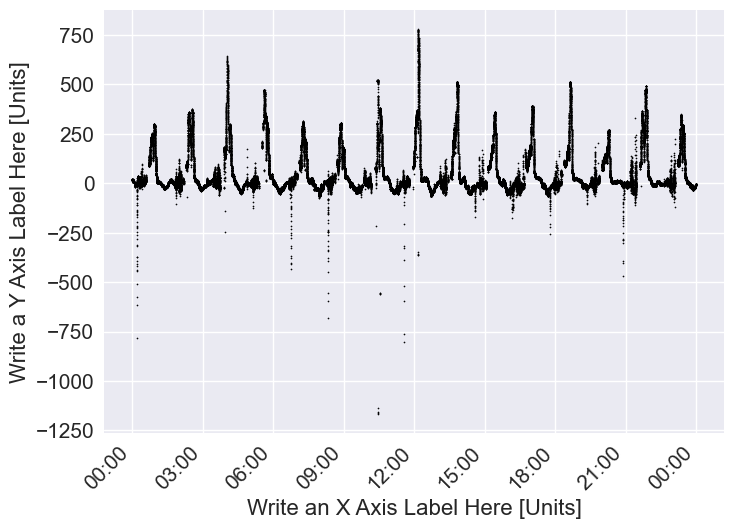

In [89]:
plt.scatter(IVM_data['time'], IVM_data['ICON_L27_Ion_Velocity_Meridional'], s=0.75, color = "black")
plt.xlabel("Write an X Axis Label Here [Units]")
plt.ylabel("Write a Y Axis Label Here [Units]")

# Set tick format
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Rotate labels
plt.xticks(rotation=45, ha='right')

plt.show()

Now let's plot the meridional ion velocity as a function of Solar Local Time.

Identify the variable in the list of IVM_data variables that corresponds to the Solar Local Times that ICON measures. Then, fill in the blank in the code below to plot the meridional ion velocity as a function of Solar Local Time.

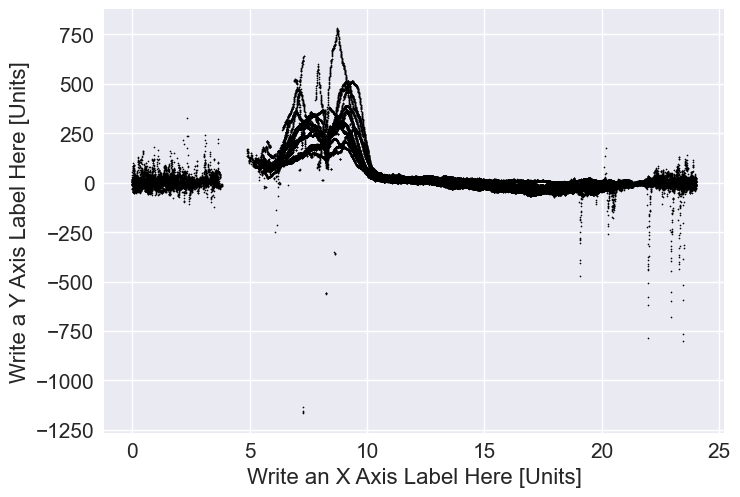

In [ ]:
##### Write code to plot the data here. #####
plt.xlabel("Write an X Axis Label Here [Units]")
plt.ylabel("Write a Y Axis Label Here [Units]")
plt.show()

Notice how the data isn't perfectly smooth. There are some odd spikes here and there. This isn't always corresponding to something physical. It could just be that the data quality isn't very good. Let's filter out all the bad data.

The ICON IVM dataset has quality flags called ICON_L27_DM_Flag and ICON_L27_RPA_Flag. The highest quality of ICON data corresponds to when both flags are 0. Let's remake our plots, using only the highest quality data.

In [90]:
# Create a data quality filter
good_data_quality = (IVM_data['ICON_L27_DM_Flag'] == 0) & (IVM_data['ICON_L27_RPA_Flag'] == 0)

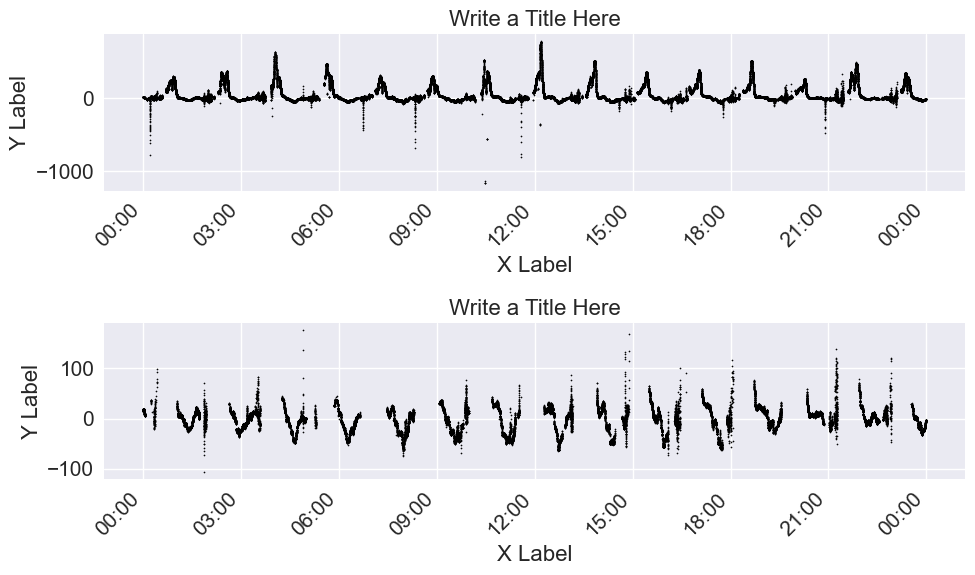

In [91]:
# First let's plot the meridional ion velocity as a function of time

# Create two plots: one with the quality filter applied and one with no data quality checks
plt.figure(figsize=(10,6)) # Create a figure that is 8 inches wide and 4 inches tall
plt.subplot(2,1,1)        # The figure should have three rows and one column. We'll start plotting on the first of the two subplots
plt.scatter(IVM_data['time'].values, IVM_data['ICON_L27_Ion_Velocity_Meridional'], s=0.75, color = "black") # Plot the IVM data
plt.xlabel("") # Write an X Axis Label Here [Units]
plt.ylabel("") # Write a Y Axis Label Here [Units]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # Set tick format
plt.xticks(rotation=45, ha='right') # Rotate labels
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.title("Write a Title Here")

plt.subplot(2,1,2)        # The figure should have three rows and one column. We'll start plotting on the second of the two subplots
plt.scatter(IVM_data['time'].values[good_data_quality], IVM_data['ICON_L27_Ion_Velocity_Meridional'][good_data_quality], s=0.75, color = "black") # Plot the high quality IVM data
plt.xlabel("") # Write an X Axis Label Here [Units]
plt.ylabel("") # Write a Y Axis Label Here [Units]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # Set tick format
plt.xticks(rotation=45, ha='right') # Rotate labels
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.title("Write a Title Here")

plt.tight_layout() # This helps make the plot look nice
plt.show()

Now let's do the same thing, this time plotting ion meridional velocity against solar local time (SLT).

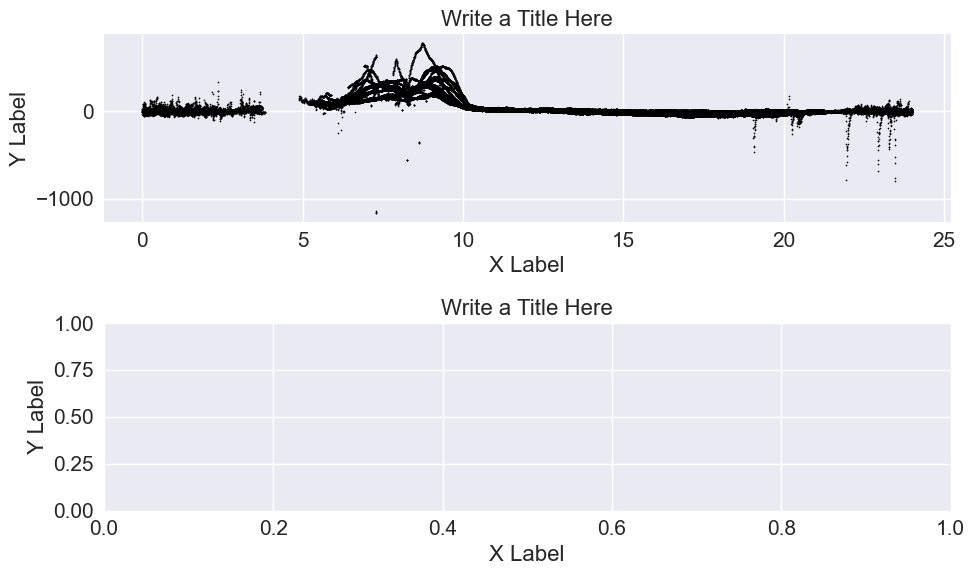

In [80]:
# First let's plot the meridional ion velocity as a function of time

# Create two plots: one with the quality filter applied and one with no data quality checks
plt.figure(figsize=(10,6)) # Create a figure that is 8 inches wide and 4 inches tall
plt.subplot(2,1,1)        # The figure should have three rows and one column. We'll start plotting on the first of the two subplots
plt.scatter(IVM_data['ICON_L27_Solar_Local_Time'].values, IVM_data['ICON_L27_Ion_Velocity_Meridional'], s=0.75, color = "black") # Plot the IVM data
plt.xlabel("") # Write an X Axis Label Here [Units]
plt.ylabel("") # Write a Y Axis Label Here [Units]
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.title("Write a Title Here")

plt.subplot(2,1,2)        # The figure should have three rows and one column. We'll start plotting on the second of the two subplots
##### Plot the data with high quality flags here. #####
plt.xlabel("") # Write an X Axis Label Here [Units]
plt.ylabel("") # Write a Y Axis Label Here [Units]
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.title("Write a Title Here")

plt.tight_layout() # This helps make the plot look nice
plt.show()

This is great, but it doesn't really give as a sense for where the ICON satellite is when making these measurements. Let's plot meridional ion velocity for one ICON orbit, and also plot where ICON is as it is making those measurements.

In [93]:
# Print all the ICON orbit numbers
print(IVM_data['ICON_L27_Orbit_Number'].values)

[4797. 4797. 4797. ... 4812. 4812. 4812.]


In [98]:
# Create a filter to select data from only one orbit
orbit_filter = IVM_data['ICON_L27_Orbit_Number'] == 4812

In [100]:
IVM_data['ICON_L27_Orbit_Number'].shape

(86400,)

In [101]:
IVM_data['ICON_L27_Longitude'].shape

(86400,)

/var/folders/s2/g3vn9c5d1jx0kqg2wn30k8540000gn/T/ipykernel_18085/357967081.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


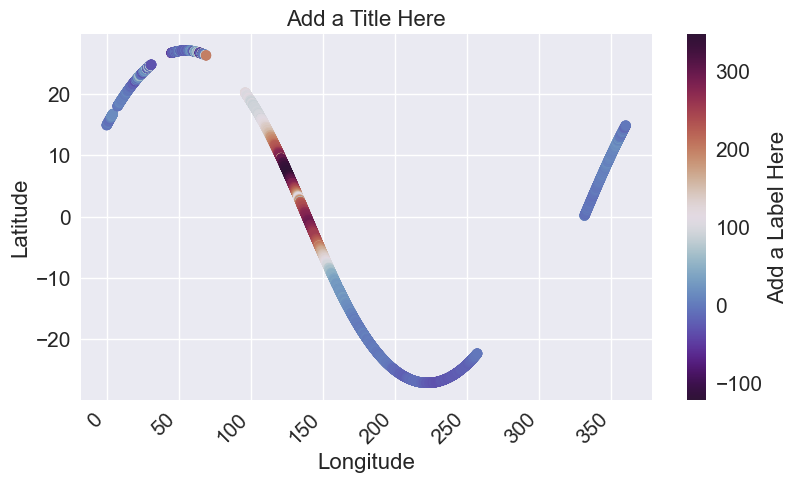

In [108]:
fig, ax = plt.subplots()

im=ax.scatter(IVM_data['ICON_L27_Longitude'].values[orbit_filter], 
              IVM_data['ICON_L27_Latitude'].values[orbit_filter], 
              c=IVM_data['ICON_L27_Ion_Velocity_Meridional'][orbit_filter],
              cmap='twilight_shifted'
    )
ax.set_title('Add a Title Here')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
color_bar=fig.colorbar(im)
color_bar.set_label('Add a Label Here')

plt.tight_layout(rect=[0, 0.0, 1.05, 0.95])
fig.autofmt_xdate(rotation=45)

plt.legend()
plt.show()

Now try to recreate the above plot, but this time only plotting data of the highest quality

HINT: Look at where we put the filter to select data from just one orbit in the code block above. Review how we filtered for good data in the previous section

/var/folders/s2/g3vn9c5d1jx0kqg2wn30k8540000gn/T/ipykernel_18085/1732420003.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


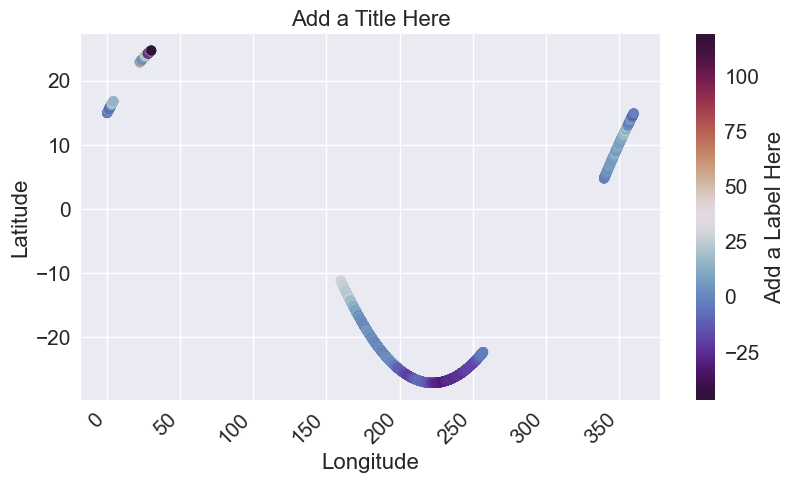

In [ ]:
fig, ax = plt.subplots()

### Write code to plot data here ###
ax.set_title('Add a Title Here')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
color_bar=fig.colorbar(im)
color_bar.set_label('Add a Label Here')

plt.tight_layout(rect=[0, 0.0, 1.05, 0.95])
fig.autofmt_xdate(rotation=45)

plt.legend()
plt.show()

# Explore!

Now you have learned some of the basics when it comes to filtering and plotting data from satellites. Explore plotting other variables in the ICON dataset. Do you notice any interesting trends or patterns?